<a href="https://colab.research.google.com/github/eboekenh/books-scraper/blob/main/books_scraper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📚 Books to Scrape — Web Scraping with Python

This notebook scrapes all books from [books.toscrape.com](https://books.toscrape.com) and saves the results to a CSV file.

**What we extract per book:**
- Title (full, not truncated)
- Price (as a float)
- Star rating (as an integer 1–5)
- Availability
- URL

**Libraries used:** `requests`, `beautifulsoup4`, `pandas`, `matplotlib`

## 1. Install & Import Libraries

In [8]:
# Run this cell only if libraries are not installed
!pip install requests beautifulsoup4 pandas matplotlib

In [9]:
import csv
import requests
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from urllib.parse import urljoin

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Configuration

In [10]:
BASE_URL    = "https://books.toscrape.com/"
OUTPUT_FILE = "books.csv"

# Maps rating words to integers
RATING_MAP = {
    "Zero":  0,
    "One":   1,
    "Two":   2,
    "Three": 3,
    "Four":  4,
    "Five":  5,
}

# Polite browser-like User-Agent header
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    )
}

print("✅ Configuration set!")

✅ Configuration set!


## 3. Fetch the Page

In [11]:
def fetch_page(url):
    """Fetch the HTML content of a page."""
    try:
        response = requests.get(url, headers=HEADERS, timeout=10)
        response.raise_for_status()
        print(f"✅ Status: {response.status_code} | Size: {len(response.text):,} chars")
        return response.text
    except requests.RequestException as e:
        print(f"❌ Error: {e}")
        return None

html = fetch_page(BASE_URL)

✅ Status: 200 | Size: 51,294 chars


## 4. Parse HTML & Find Book Cards

In [12]:
soup  = BeautifulSoup(html, "html.parser")
cards = soup.find_all("article", class_="product_pod")

print(f"📦 Found {len(cards)} book cards on the homepage")
print(f"\nFirst card HTML preview:")
print(cards[0].prettify()[:500])

📦 Found 20 book cards on the homepage

First card HTML preview:
<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/ind


## 5. Extraction Functions

One small function per field — clean and easy to test individually.

In [13]:
import re

def extract_title(card):
    """Full title from the 'title' attribute (visible text is truncated)."""
    return card.find("h3").find("a")["title"]

def extract_price(card):
    """Price as a float, with £ sign stripped."""
    raw = card.find("p", class_="price_color").get_text(strip=True)
    # Use a regular expression to remove all characters that are not digits or a dot
    cleaned_price = re.sub(r'[^\d.]', '', raw)
    return float(cleaned_price)

def extract_rating(card):
    """Star rating as integer 0–5."""
    classes = card.find("p", class_="star-rating")["class"]
    return RATING_MAP.get(classes[1], 0)

def extract_availability(card):
    """Availability text (e.g. 'In stock')."""
    return card.find("p", class_="instock availability").get_text(strip=True)

def extract_url(card, base_url):
    """Full absolute URL to the book's detail page."""
    relative = card.find("h3").find("a")["href"]
    return urljoin(base_url, relative)

def extract_book(card, base_url):
    """Extract all fields from one book card and return as a dict."""
    return {
        "title":        extract_title(card),
        "price":        extract_price(card),
        "rating":       extract_rating(card),
        "availability": extract_availability(card),
        "url":          extract_url(card, base_url),
    }

# Quick test on the first card
print("🧪 Test on first card:")
print(extract_book(cards[0], BASE_URL))

🧪 Test on first card:
{'title': 'A Light in the Attic', 'price': 51.77, 'rating': 3, 'availability': 'In stock', 'url': 'https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html'}


## 6. Scrape All Books

In [14]:
def stars(rating):
    return "\u2605" * rating + "\u2606" * (5 - rating)

books = []

for i, card in enumerate(cards, start=1):
    book = extract_book(card, BASE_URL)
    books.append(book)
    title = book["title"][:45].ljust(45)
    print(f"{i:>3}. {title}  £{book['price']:>6.2f}  {stars(book['rating'])}")

print(f"\n✅ Scraped {len(books)} books total")

  1. A Light in the Attic                           £ 51.77  ★★★☆☆
  2. Tipping the Velvet                             £ 53.74  ★☆☆☆☆
  3. Soumission                                     £ 50.10  ★☆☆☆☆
  4. Sharp Objects                                  £ 47.82  ★★★★☆
  5. Sapiens: A Brief History of Humankind          £ 54.23  ★★★★★
  6. The Requiem Red                                £ 22.65  ★☆☆☆☆
  7. The Dirty Little Secrets of Getting Your Drea  £ 33.34  ★★★★☆
  8. The Coming Woman: A Novel Based on the Life o  £ 17.93  ★★★☆☆
  9. The Boys in the Boat: Nine Americans and Thei  £ 22.60  ★★★★☆
 10. The Black Maria                                £ 52.15  ★☆☆☆☆
 11. Starving Hearts (Triangular Trade Trilogy, #1  £ 13.99  ★★☆☆☆
 12. Shakespeare's Sonnets                          £ 20.66  ★★★★☆
 13. Set Me Free                                    £ 17.46  ★★★★★
 14. Scott Pilgrim's Precious Little Life (Scott P  £ 52.29  ★★★★★
 15. Rip it Up and Start Again                      £ 35.02  ★

## 7. Load into a DataFrame & Preview

In [15]:
df = pd.DataFrame(books)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (20, 5)


,title,price,rating,availability,url
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...
5,The Requiem Red,22.65,1,In stock,https://books.toscrape.com/catalogue/the-requi...
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,In stock,https://books.toscrape.com/catalogue/the-dirty...
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,In stock,https://books.toscrape.com/catalogue/the-comin...
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,In stock,https://books.toscrape.com/catalogue/the-boys-...
9,The Black Maria,52.15,1,In stock,https://books.toscrape.com/catalogue/the-black...


## 8. Summary Statistics

In [16]:
print("📊 Summary Statistics")
print("=" * 35)
print(f"Total books     : {len(df)}")
print(f"Average price   : £{df['price'].mean():.2f}")
print(f"Cheapest book   : £{df['price'].min():.2f}")
print(f"Most expensive  : £{df['price'].max():.2f}")
print(f"Average rating  : {df['rating'].mean():.2f} / 5")
print()
print("Rating distribution:")
print(df['rating'].value_counts().sort_index())

📊 Summary Statistics
Total books     : 20
Average price   : £38.05
Cheapest book   : £13.99
Most expensive  : £57.25
Average rating  : 2.85 / 5

Rating distribution:
rating
1    6
2    3
3    3
4    4
5    4
Name: count, dtype: int64


## 9. Visualisations

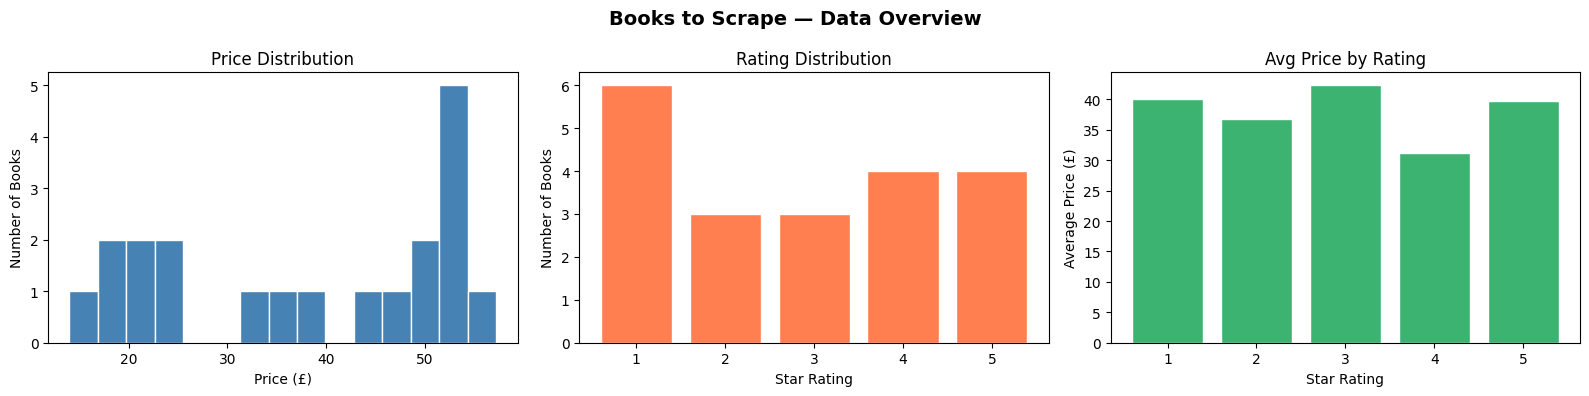

📈 Chart saved as books_analysis.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Books to Scrape — Data Overview", fontsize=14, fontweight="bold")

# 1. Price distribution
axes[0].hist(df["price"], bins=15, color="steelblue", edgecolor="white")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (£)")
axes[0].set_ylabel("Number of Books")

# 2. Rating distribution
rating_counts = df["rating"].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values, color="coral", edgecolor="white")
axes[1].set_title("Rating Distribution")
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("Number of Books")
axes[1].set_xticks([1, 2, 3, 4, 5])

# 3. Average price per rating
avg_price = df.groupby("rating")["price"].mean()
axes[2].bar(avg_price.index, avg_price.values, color="mediumseagreen", edgecolor="white")
axes[2].set_title("Avg Price by Rating")
axes[2].set_xlabel("Star Rating")
axes[2].set_ylabel("Average Price (£)")
axes[2].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig("books_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("📈 Chart saved as books_analysis.png")

## 10. Save to CSV

In [18]:
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")
print(f"💾 Saved {len(df)} books to '{OUTPUT_FILE}'")
print("\nFirst few rows of CSV:")
print(df[["title", "price", "rating"]].head())

💾 Saved 20 books to 'books.csv'

First few rows of CSV:
                                   title  price  rating
0                   A Light in the Attic  51.77       3
1                     Tipping the Velvet  53.74       1
2                             Soumission  50.10       1
3                          Sharp Objects  47.82       4
4  Sapiens: A Brief History of Humankind  54.23       5


## 11. (Colab only) Download the CSV

In [19]:
# Only run this cell if you are on Google Colab
try:
    from google.colab import files
    files.download(OUTPUT_FILE)
    print("📥 Download started!")
except ImportError:
    print("ℹ️ Not running on Colab — find your CSV in the same folder as this notebook.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download started!
